# Quaver Backtest Example

This notebook demonstrates **quaver**'s backtesting capabilities using real stock data from Yahoo Finance.

We will:
1. Discover available strategies via the `StrategyRegistry`
2. Download OHLCV data with `yfinance`
3. Run single-asset backtests (Mean Reversion, VSA Stopping Volume)
4. Visualise equity curves and analyse trades
5. Compare strategy metrics side-by-side
6. Run a multi-asset pairs backtest (AAPL vs MSFT)

## 1. Imports & Setup

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# quaver imports
from quaver.strategies.registry import StrategyRegistry
import quaver.strategies  # noqa: F401 -- triggers auto-registration of all built-in engines
from quaver.backtest import run_backtest, run_multi_asset_backtest

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

## 2. Discover Available Strategies

In [2]:
print("Registered engines:", StrategyRegistry.list_engines())

for name in StrategyRegistry.list_engines():
    cls = StrategyRegistry.get(name)
    kind = StrategyRegistry.get_strategy_kind(name)
    defaults = cls.get_default_parameters()
    print(f"\n--- {name} ({kind}) ---")
    print(f"  Display name: {cls.display_name}")
    print(f"  Description:  {cls.description}")
    print(f"  Defaults:     {defaults}")

Registered engines: ['mean_reversion', 'pairs_mean_reversion', 'regime_mean_reversion', 'vsa_stopping_volume']

--- mean_reversion (single) ---
  Display name: Mean Reversion
  Description:  Dual moving-average mean reversion. BUY when fast MA is below slow MA by more than threshold (oversold). SELL when above (overbought).
  Defaults:     {'fast_period': 20, 'slow_period': 50, 'threshold': 0.02}

--- pairs_mean_reversion (multi) ---
  Display name: Pairs Mean Reversion
  Description:  Classical two-leg statistical arbitrage. Trades the normalised spread between two instruments using z-score entry/exit thresholds.
  Defaults:     {'spread_window': 60, 'entry_z': 2.0, 'exit_z': 0.5}

--- regime_mean_reversion (single) ---
  Display name: Regime Mean Reversion
  Description:  Regime-based probabilistic mean-reversion strategy. Classifies markets into regimes using ADX, Bollinger Band Width, and volume, then generates signals only when expanding-window conditional probabilities confirm re

## 3. Download Stock Data

yfinance returns columns like `Open, High, Low, Close, Volume` (capitalised).  
quaver expects `ts, open, high, low, close, volume` (lowercase).  
We define a helper to convert.

In [3]:
def yf_to_quaver(ticker: str, period: str = "2y", interval: str = "1d") -> pd.DataFrame:
    """Download OHLCV data from yfinance and format it for quaver."""
    df = yf.download(ticker, period=period, interval=interval, progress=False)
    # Flatten multi-level columns if present (single ticker)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df.rename(columns=str.lower)
    df = df.reset_index()
    # Rename the date/datetime index column to 'ts'
    date_col = [c for c in df.columns if c.lower() in ("date", "datetime")][0]
    df = df.rename(columns={date_col: "ts"})
    return df[["ts", "open", "high", "low", "close", "volume"]]

In [4]:
aapl = yf_to_quaver("AAPL")
print(f"AAPL: {len(aapl)} rows, {aapl['ts'].min()} to {aapl['ts'].max()}")
aapl.tail()

AAPL: 501 rows, 2024-03-07 00:00:00 to 2026-03-06 00:00:00


Price,ts,open,high,low,close,volume
496,2026-03-02,262.410004,266.529999,260.200012,264.720001,41827900
497,2026-03-03,263.480011,265.559998,260.130005,263.750000,38568900
498,2026-03-04,264.649994,266.149994,261.420013,262.519989,39803100
499,2026-03-05,260.790009,261.559998,257.250000,260.290009,49658600
500,2026-03-06,258.630005,258.769989,254.369995,257.459991,41094000


## 4. Strategy 1 -- Mean Reversion Backtest

In [5]:
mr_defaults = StrategyRegistry.get("mean_reversion").get_default_parameters()
print("Mean Reversion defaults:", mr_defaults)

mr_result = run_backtest(
    engine_name="mean_reversion",
    parameters=mr_defaults,
    candles=aapl,
    instrument_id="AAPL",
    initial_capital=10_000,
    quantity_per_trade=10,
)

print(f"\nTotal trades: {mr_result.total_trades}")
mr_result.summary()

Mean Reversion defaults: {'fast_period': 20, 'slow_period': 50, 'threshold': 0.02}

Total trades: 2


{'instrument_id': 'AAPL',
 'initial_capital': 10000,
 'final_cash': 9965.01,
 'total_return_pct': -0.35,
 'total_trades': 2,
 'winning_trades': 1,
 'losing_trades': 1,
 'win_rate_pct': 50.0,
 'avg_pnl': -17.4928,
 'profit_factor': 0.7416,
 'sharpe_ratio': -1.6653,
 'max_drawdown_pct': 0.0}

## 5. Visualise Equity Curve

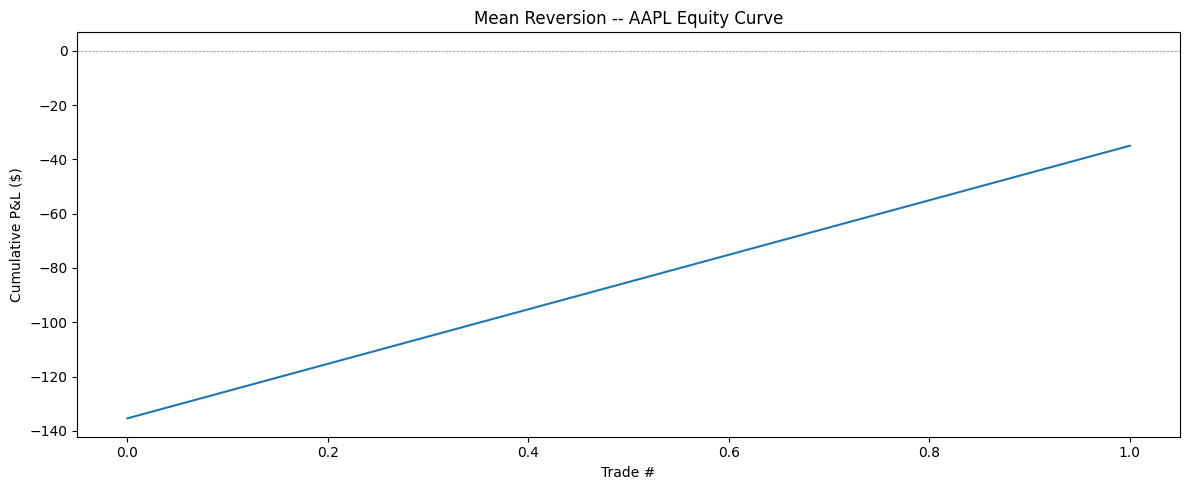

In [7]:
fig, ax = plt.subplots()
cpnl = mr_result.cumulative_pnl
ax.plot(range(len(cpnl)), cpnl, linewidth=1.5)
ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
ax.set_xlabel("Trade #")
ax.set_ylabel("Cumulative P&L ($)")
ax.set_title("Mean Reversion -- AAPL Equity Curve")
plt.tight_layout()
plt.show()

## 6. Trade Analysis

In [8]:
trades_df = pd.DataFrame([
    {
        "entry_ts": t.entry_ts,
        "exit_ts": t.exit_ts,
        "direction": t.direction.value,
        "entry_price": round(t.entry_price, 2),
        "exit_price": round(t.exit_price, 2),
        "quantity": t.quantity,
        "pnl": round(t.pnl, 2),
    }
    for t in mr_result.trades
])
trades_df

,entry_ts,exit_ts,direction,entry_price,exit_price,quantity,pnl
0,2025-02-03,2025-07-25,buy,226.77,213.23,10,-135.40
1,2026-01-21,2026-03-06,buy,247.42,257.46,10,100.42


## 7. Strategy 2 -- VSA Stopping Volume

Run with `allow_shorting=True` so SELL signals can open short positions.

In [10]:
vsa_defaults = StrategyRegistry.get("vsa_stopping_volume").get_default_parameters()
print("VSA defaults:", vsa_defaults)

vsa_result = run_backtest(
    engine_name="vsa_stopping_volume",
    parameters=vsa_defaults,
    candles=aapl,
    instrument_id="AAPL",
    initial_capital=10_000,
    quantity_per_trade=10,
    allow_shorting=True,
)

print(f"\nTotal trades: {vsa_result.total_trades}")
vsa_result.summary()

VSA defaults: {'sma_window': 20, 'trend_sma': 20, 'vol_high': 1.5, 'vol_low': 0.7, 'spread_big': 1.3, 'spread_small': 0.7, 'stopping_vol_rel': 2.0, 'buy_close_pos_min': 0.4, 'sell_close_pos_max': 0.6, 'enable_buy': True, 'enable_sell': True}

Total trades: 0


{'instrument_id': 'AAPL',
 'initial_capital': 10000,
 'final_cash': 10000,
 'total_return_pct': 0.0,
 'total_trades': 0,
 'winning_trades': 0,
 'losing_trades': 0,
 'win_rate_pct': 0.0,
 'avg_pnl': 0.0,
 'profit_factor': inf,
 'sharpe_ratio': 0.0,
 'max_drawdown_pct': 0.0}

## 8. Strategy Comparison

In [11]:
comparison = pd.DataFrame({
    "Mean Reversion": mr_result.summary(),
    "VSA Stopping Volume": vsa_result.summary(),
}).T
comparison

,instrument_id,initial_capital,final_cash,total_return_pct,total_trades,winning_trades,losing_trades,win_rate_pct,avg_pnl,profit_factor,sharpe_ratio,max_drawdown_pct
Mean Reversion,AAPL,10000,9965.01,-0.35,2,1,1,50.0,-17.4928,0.7416,-1.6653,0.0
VSA Stopping Volume,AAPL,10000,10000,0.0,0,0,0,0.0,0.0,inf,0.0,0.0


## 9. Strategy 3 -- Pairs Mean Reversion (Multi-Asset)

This strategy trades the normalised price spread between AAPL and MSFT.

In [12]:
msft = yf_to_quaver("MSFT")
print(f"MSFT: {len(msft)} rows, {msft['ts'].min()} to {msft['ts'].max()}")
msft.tail()

MSFT: 501 rows, 2024-03-07 00:00:00 to 2026-03-06 00:00:00


Price,ts,open,high,low,close,volume
496,2026-03-02,392.859985,401.190002,390.630005,398.549988,35474900
497,2026-03-03,393.140015,406.700012,392.670013,403.929993,38199200
498,2026-03-04,401.269989,411.029999,400.309998,405.200012,35808000
499,2026-03-05,404.420013,411.609985,404.399994,410.679993,39001300
500,2026-03-06,409.200012,413.049988,408.510010,408.959991,31085000


In [14]:
pairs_defaults = StrategyRegistry.get("pairs_mean_reversion").get_default_parameters()
pairs_params = {
    **pairs_defaults,
    "instrument_a": "AAPL",
    "instrument_b": "MSFT",
}
print("Pairs params:", pairs_params)

pairs_results = run_multi_asset_backtest(
    engine_name="pairs_mean_reversion",
    parameters=pairs_params,
    candles_map={"AAPL": aapl, "MSFT": msft},
    initial_capital=10_000,
    quantity_per_trade=10,
    allow_shorting=True,
)

for inst_id, result in pairs_results.items():
    print(f"\n=== {inst_id} ===")
    for k, v in result.summary().items():
        print(f"  {k}: {v}")

Pairs params: {'spread_window': 60, 'entry_z': 2.0, 'exit_z': 0.5, 'instrument_a': 'AAPL', 'instrument_b': 'MSFT'}

=== AAPL ===
  instrument_id: AAPL
  initial_capital: 10000
  final_cash: 10812.32
  total_return_pct: 8.12
  total_trades: 8
  winning_trades: 7
  losing_trades: 1
  win_rate_pct: 87.5
  avg_pnl: 101.5403
  profit_factor: 3.5577
  sharpe_ratio: 8.3356
  max_drawdown_pct: -3.18

=== MSFT ===
  instrument_id: MSFT
  initial_capital: 10000
  final_cash: 9542.4
  total_return_pct: -4.58
  total_trades: 7
  winning_trades: 2
  losing_trades: 5
  win_rate_pct: 28.57
  avg_pnl: -65.3711
  profit_factor: 0.6857
  sharpe_ratio: -2.1894
  max_drawdown_pct: -8.68


## 10. Pairs Spread Visualisation

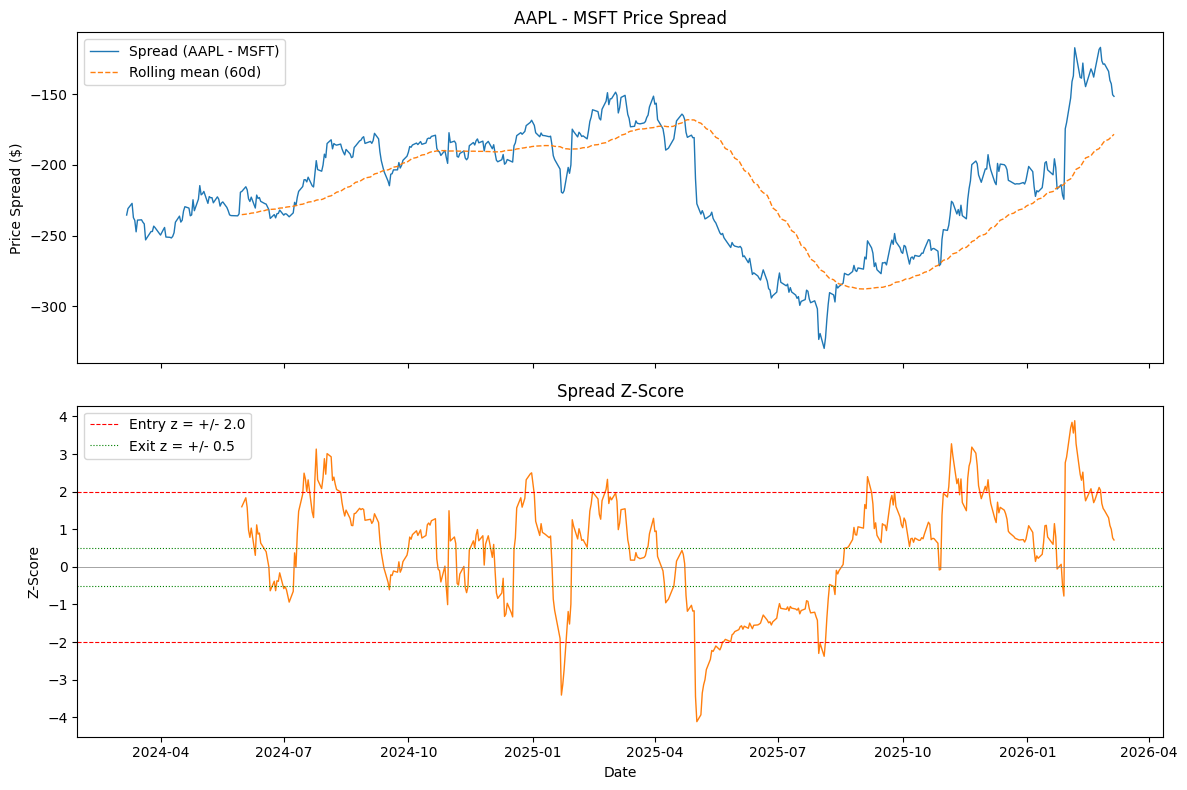

In [16]:
# Align the two price series on overlapping dates
merged = pd.merge(
    aapl[["ts", "close"]].rename(columns={"close": "aapl_close"}),
    msft[["ts", "close"]].rename(columns={"close": "msft_close"}),
    on="ts",
)

merged["spread"] = merged["aapl_close"] - merged["msft_close"]

window = pairs_params["spread_window"]
merged["spread_mean"] = merged["spread"].rolling(window).mean()
merged["spread_std"] = merged["spread"].rolling(window).std(ddof=1)
merged["z_score"] = (merged["spread"] - merged["spread_mean"]) / merged["spread_std"]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Spread
axes[0].plot(merged["ts"], merged["spread"], label="Spread (AAPL - MSFT)", linewidth=1)
axes[0].plot(merged["ts"], merged["spread_mean"], label=f"Rolling mean ({window}d)",
             linewidth=1, linestyle="--")
axes[0].set_ylabel("Price Spread ($)")
axes[0].set_title("AAPL - MSFT Price Spread")
axes[0].legend()

# Z-score
axes[1].plot(merged["ts"], merged["z_score"], linewidth=1, color="tab:orange")
axes[1].axhline(pairs_params["entry_z"], color="red", linestyle="--", linewidth=0.8,
                label=f"Entry z = +/- {pairs_params['entry_z']}")
axes[1].axhline(-pairs_params["entry_z"], color="red", linestyle="--", linewidth=0.8)
axes[1].axhline(pairs_params["exit_z"], color="green", linestyle=":", linewidth=0.8,
                label=f"Exit z = +/- {pairs_params['exit_z']}")
axes[1].axhline(-pairs_params["exit_z"], color="green", linestyle=":", linewidth=0.8)
axes[1].axhline(0, color="grey", linewidth=0.5)
axes[1].set_ylabel("Z-Score")
axes[1].set_xlabel("Date")
axes[1].set_title("Spread Z-Score")
axes[1].legend()

plt.tight_layout()
plt.show()

## Summary

In this notebook we demonstrated the core quaver workflow:

- **Strategy discovery** via `StrategyRegistry.list_engines()` and `get_default_parameters()`
- **Single-asset backtesting** with `run_backtest()` for Mean Reversion and VSA Stopping Volume
- **Equity curve visualisation** using the `cumulative_pnl` property
- **Trade-level analysis** by converting `TradeRecord` objects to a DataFrame
- **Strategy comparison** via side-by-side `summary()` metrics
- **Multi-asset backtesting** with `run_multi_asset_backtest()` for Pairs Mean Reversion
- **Spread and z-score visualisation** showing the statistical arbitrage dynamics

All strategies use walk-forward evaluation with no look-ahead bias.